In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import joblib
from tqdm import tqdm

print("PyTorch:", torch.__version__)

PyTorch: 2.14.0+cu130


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
DATA_DIR = "/home/abhay/projects/MedVision_Ai/backend/dataset/brain_tumer"

TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR = os.path.join(DATA_DIR, "Testing")

MODEL_DIR = "/home/abhay/projects/MedVision_Ai/backend/dataset/brain_tumer/weights"

os.makedirs(MODEL_DIR, exist_ok=True)

print("Training:", TRAIN_DIR)
print("Testing:", TEST_DIR)
print("Model directory:", MODEL_DIR)

Training: /home/abhay/projects/MedVision_Ai/backend/dataset/brain_tumer/Training
Testing: /home/abhay/projects/MedVision_Ai/backend/dataset/brain_tumer/Testing
Model directory: /home/abhay/projects/MedVision_Ai/backend/dataset/brain_tumer/weights


In [5]:
print("Training exists:", os.path.exists(TRAIN_DIR))
print("Testing exists:", os.path.exists(TEST_DIR))

print("\nTraining classes:")
print(os.listdir(TRAIN_DIR))

print("\nTesting classes:")
print(os.listdir(TEST_DIR))

Training exists: True
Testing exists: True

Training classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

Testing classes:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
def count_images(folder):
    counts = {}

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".bmp")
                )
            ])

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\nTesting:")
for cls, count in test_counts.items():
    print(f"{cls}: {count}")

Training:
glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400

Testing:
glioma: 400
meningioma: 400
notumor: 400
pituitary: 400


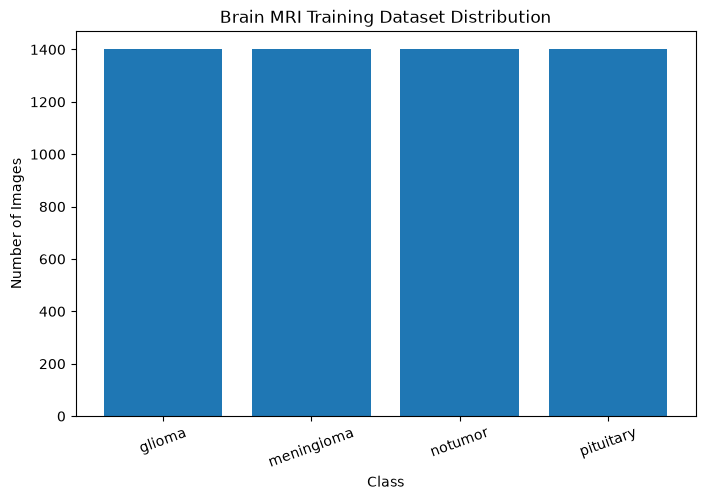

In [7]:
classes = list(train_counts.keys())
counts = list(train_counts.values())

plt.figure(figsize=(8, 5))

plt.bar(classes, counts)

plt.title("Brain MRI Training Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=20)

plt.show()

In [8]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("\nTraining images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Training images: 5600
Testing images: 1600


In [10]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training samples:", len(train_subset))
print("Validation samples:", len(val_subset))
print("Testing samples:", len(test_dataset))

Training samples: 4480
Validation samples: 1120
Testing samples: 1600


In [11]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created")

DataLoaders created


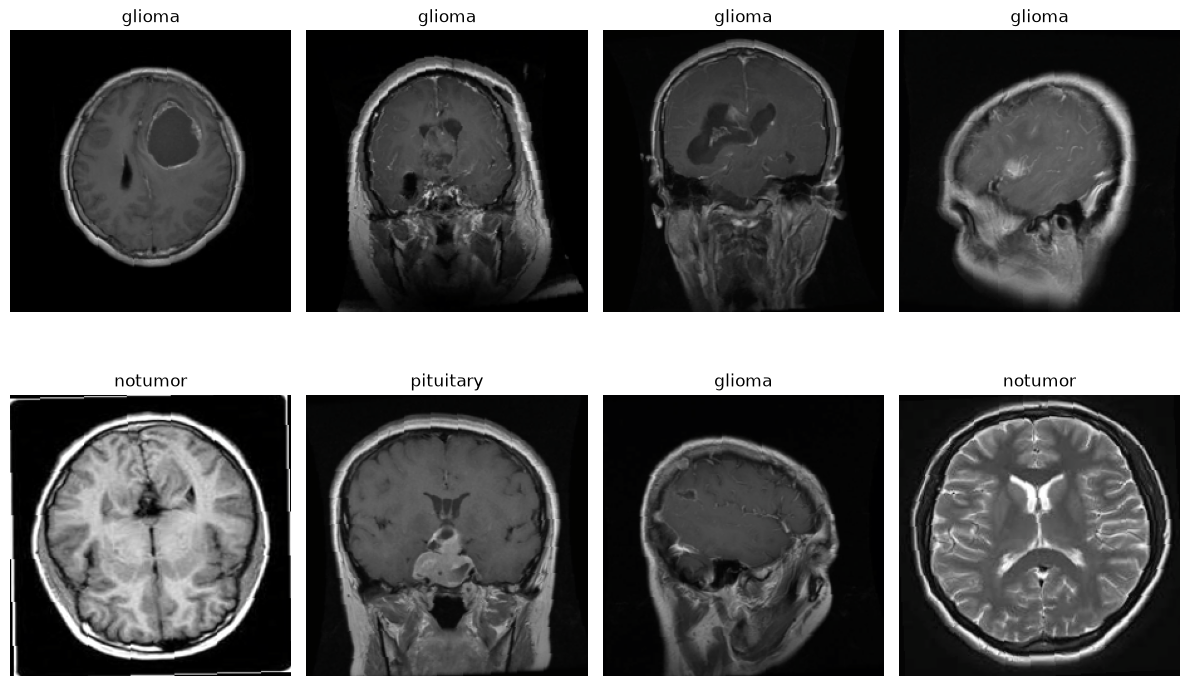

In [12]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(min(8, len(images))):

    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization approximately
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    plt.title(
        train_dataset.classes[labels[i].item()]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
model = models.densenet121(
    weights=models.DenseNet121_Weights.DEFAULT
)

print(model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=T

In [14]:
NUM_CLASSES = 4

model.classifier = nn.Linear(
    model.classifier.in_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.classifier)

Linear(in_features=1024, out_features=4, bias=True)


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [16]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        loader,
        desc="Training"
    )

    for images, labels in progress:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

        progress.set_postfix(
            loss=loss.item()
        )

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [17]:
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        progress = tqdm(
            loader,
            desc="Validation"
        )

        for images, labels in progress:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [18]:
NUM_EPOCHS = 5

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "brain_mri_model.pt"
)

best_val_loss = float("inf")

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):

    print(
        f"\n========== Epoch "
        f"{epoch + 1}/{NUM_EPOCHS} =========="
    )

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: "
        f"{train_accuracy * 100:.2f}%"
    )

    print(
        f"Validation Loss: "
        f"{val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: "
        f"{val_accuracy * 100:.2f}%"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print(
            "✓ Best model saved:"
        )

        print(MODEL_PATH)


========== Epoch 1/5 ==========


Validation: 100%|██████████| 70/70 [01:47<00:00,  1.54s/it]


Train Loss: 0.3055
Train Accuracy: 89.53%
Validation Loss: 0.1022
Validation Accuracy: 96.16%
✓ Best model saved:
/home/abhay/projects/MedVision_Ai/backend/dataset/brain_tumer/weights/brain_mri_model.pt

========== Epoch 2/5 ==========


Validation: 100%|██████████| 70/70 [01:37<00:00,  1.39s/it]


Train Loss: 0.1160
Train Accuracy: 96.34%
Validation Loss: 0.1115
Validation Accuracy: 95.80%

========== Epoch 3/5 ==========


...

Train Loss: 0.0772
Train Accuracy: 97.72%
Validation Loss: 0.1464
Validation Accuracy: 95.98%

========== Epoch 4/5 ==========


Validation: 100%|██████████| 70/70 [01:41<00:00,  1.45s/it]


Train Loss: 0.0367
Train Accuracy: 99.13%
Validation Loss: 0.0329
Validation Accuracy: 98.75%
✓ Best model saved:
/home/abhay/projects/MedVision_Ai/backend/dataset/brain_tumer/weights/brain_mri_model.pt

========== Epoch 5/5 ==========


Validation: 100%|██████████| 70/70 [01:40<00:00,  1.44s/it]

Train Loss: 0.0238
Train Accuracy: 99.40%
Validation Loss: 0.0449
Validation Accuracy: 98.48%


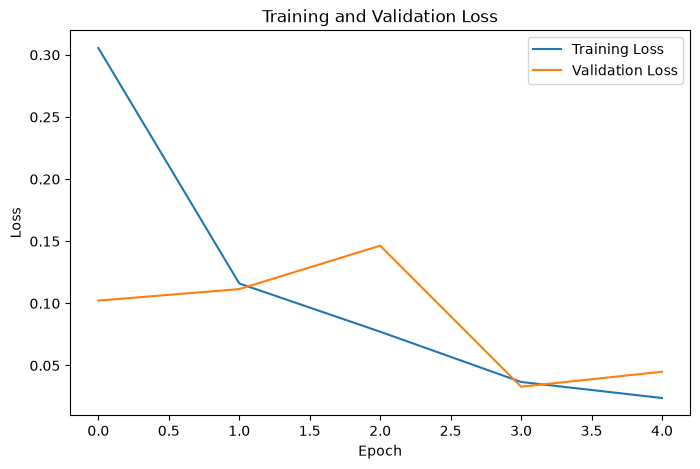

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.show()

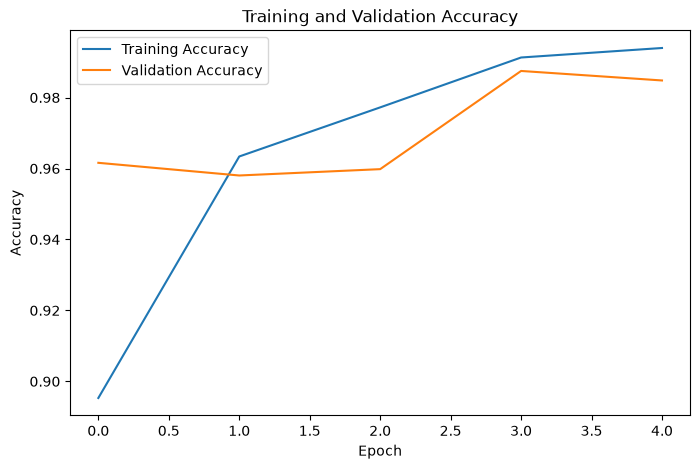

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.show()

In [21]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Testing"
    ):

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

Testing: 100%|██████████| 100/100 [02:30<00:00,  1.50s/it]


In [22]:
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Accuracy: 94.88%


In [23]:
class_names = train_dataset.classes

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

      glioma       0.99      0.81      0.89       400
  meningioma       0.92      0.99      0.95       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



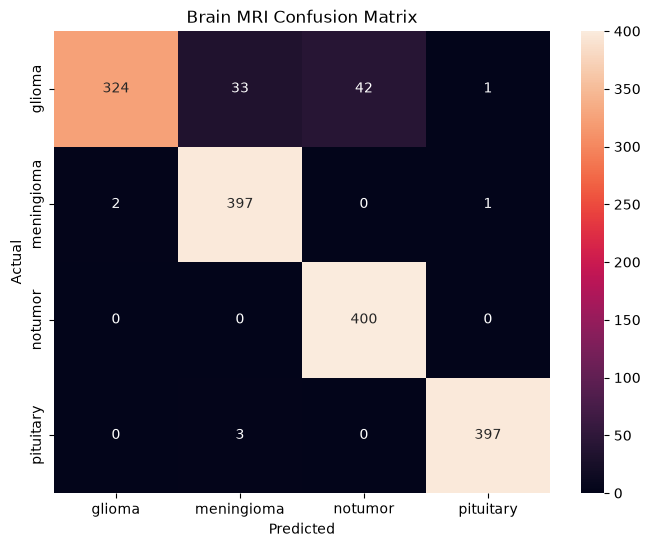

In [24]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Brain MRI Confusion Matrix"
)

plt.show()

In [25]:
CONFIG_PATH = os.path.join(
    MODEL_DIR,
    "brain_mri_config.pkl"
)

model_config = {
    "model_name": "DenseNet121",

    "modality": "brain_mri",

    "num_classes": NUM_CLASSES,

    "classes": class_names,

    "image_size": IMG_SIZE,

    "threshold": 0.5,

    "mean": [
        0.485,
        0.456,
        0.406
    ],

    "std": [
        0.229,
        0.224,
        0.225
    ],

    "model_file": "brain_mri_model.pt",

    "test_accuracy": float(
        test_accuracy
    )
}

joblib.dump(
    model_config,
    CONFIG_PATH
)

print(
    "✓ Configuration saved:"
)

print(CONFIG_PATH)

✓ Configuration saved:
/home/abhay/projects/MedVision_Ai/backend/dataset/brain_tumer/weights/brain_mri_config.pkl


In [26]:
loaded_config = joblib.load(
    CONFIG_PATH
)

print(loaded_config)

{'model_name': 'DenseNet121', 'modality': 'brain_mri', 'num_classes': 4, 'classes': ['glioma', 'meningioma', 'notumor', 'pituitary'], 'image_size': 224, 'threshold': 0.5, 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'model_file': 'brain_mri_model.pt', 'test_accuracy': 0.94875}


In [27]:
def predict_brain_mri(
    image_path,
    model,
    config,
    device
):

    transform = transforms.Compose([
        transforms.Resize(
            (
                config["image_size"],
                config["image_size"]
            )
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=config["mean"],
            std=config["std"]
        )
    ])

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = transform(
        image
    ).unsqueeze(0)

    image_tensor = image_tensor.to(
        device
    )

    model.eval()

    with torch.no_grad():

        output = model(
            image_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )[0]

    predicted_index = torch.argmax(
        probabilities
    ).item()

    predicted_class = (
        config["classes"][predicted_index]
    )

    confidence = float(
        probabilities[predicted_index]
        .cpu()
        .item()
    )

    results = []

    for class_name, probability in zip(
        config["classes"],
        probabilities
    ):

        results.append({
            "class": class_name,
            "probability": round(
                float(
                    probability.cpu().item()
                ),
                4
            ),
            "percentage": round(
                float(
                    probability.cpu().item()
                ) * 100,
                2
            )
        })

    return {
        "prediction": predicted_class,
        "confidence": round(
            confidence * 100,
            2
        ),
        "probabilities": results
    }

In [32]:
IMAGE_PATH = "/home/abhay/projects/MedVision_Ai/backend/dataset/brain_tumer/Testing/meningioma/Te-aug-me_6.jpg"

result = predict_brain_mri(
    IMAGE_PATH,
    model,
    loaded_config,
    device
)

print("Prediction:")
print(result["prediction"])

print(
    f"Confidence: "
    f"{result['confidence']}%"
)

print("\nAll probabilities:")

for item in result["probabilities"]:

    print(
        f"{item['class']}: "
        f"{item['percentage']}%"
    )

Prediction:
meningioma
Confidence: 99.71%

All probabilities:
glioma: 0.23%
meningioma: 99.71%
notumor: 0.01%
pituitary: 0.04%


In [34]:
import torch
import joblib
import os
import torch.nn as nn
from torchvision import models

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

MODEL_PATH = "/home/abhay/projects/MedVision_Ai/backend/dataset/brain_tumer/weights/brain_mri_model.pt"

CONFIG_PATH = "/home/abhay/projects/MedVision_Ai/backend/dataset/brain_tumer/weights/brain_mri_config.pkl"

config = joblib.load(
    CONFIG_PATH
)

print(config)

{'model_name': 'DenseNet121', 'modality': 'brain_mri', 'num_classes': 4, 'classes': ['glioma', 'meningioma', 'notumor', 'pituitary'], 'image_size': 224, 'threshold': 0.5, 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'model_file': 'brain_mri_model.pt', 'test_accuracy': 0.94875}
